# Week 1 - MLS Data Exploration

In [37]:
import pandas as pd

In [38]:
sold = pd.read_csv("combined_sold.csv")
listed = pd.read_csv("combined_listings.csv")

The "sold" dataset contains properties that have closed, while the "listed" dataset contains properties that entered the market.

These represent market outcomes (sold) and market supply (listings).

In [39]:
print("Sold shape:", sold.shape)
print("Listed shape:", listed.shape)

Sold shape: (606299, 8)
Listed shape: (678378, 10)


This highlights the difference between supply (listings) and outcomes (sold).


In [40]:
print("SOLD COLUMNS:")
print(sold.columns)

print("\nLISTED COLUMNS:")
print(listed.columns)

SOLD COLUMNS:
Index(['LivingArea', 'BedroomsTotal', 'PostalCode', 'City', 'ListPrice',
       'ClosePrice', 'CloseDate', 'ListingKey'],
      dtype='object')

LISTED COLUMNS:
Index(['LivingArea', 'BedroomsTotal', 'ListingContractDate', 'PostalCode',
       'PropertyType', 'City', 'ListPrice', 'UnparsedAddress',
       'BathroomsTotalInteger', 'ListingKey'],
      dtype='object')


In [41]:
print("SOLD HEAD:")
print(sold.head())

print("\nLISTED HEAD:")
print(listed.head())

SOLD HEAD:
   LivingArea  BedroomsTotal PostalCode           City  ListPrice  ClosePrice  \
0      3040.0            5.0      94553       Martinez  1700000.0   1700000.0   
1      3517.0            6.0      90035    Los Angeles  1900000.0   1805000.0   
2      1092.0            3.0      92115      San Diego   625000.0    625000.0   
3      1696.0            4.0      94303      Palo Alto  4350000.0   4350000.0   
4      2917.0            3.0      93420  Arroyo Grande  1800000.0   1800000.0   

    CloseDate  ListingKey  
0  2024-09-16  1119992097  
1  2024-09-09  1111834163  
2  2024-09-03  1097676785  
3  2024-09-05  1095735473  
4  2024-09-06  1092526207  

LISTED HEAD:
   LivingArea  BedroomsTotal ListingContractDate PostalCode  \
0      1671.0            4.0          2024-05-31      95503   
1       667.0            1.0          2024-05-04      92101   
2      1410.0            2.0          2024-05-28      92118   
3         NaN            NaN          2024-05-31      93436   
4    

In [42]:
print("SOLD SUMMARY:")
print(sold.describe())

print("\nLISTED SUMMARY:")
print(listed.describe())

SOLD SUMMARY:
         LivingArea  BedroomsTotal     ListPrice    ClosePrice    ListingKey
count  5.626580e+05  565310.000000  6.053340e+05  6.062910e+05  6.062990e+05
mean   3.456418e+03       3.078302  8.262211e+05  8.224300e+05  1.096304e+09
std    1.212162e+06       1.433911  1.269103e+06  1.910843e+06  3.320689e+07
min    0.000000e+00       0.000000  0.000000e+00  0.000000e+00  4.214490e+08
25%    1.180000e+03       2.000000  5.000000e+04  4.500000e+04  1.075261e+09
50%    1.576000e+03       3.000000  6.249000e+05  6.200000e+05  1.095987e+09
75%    2.147000e+03       4.000000  1.035000e+06  1.050000e+06  1.117478e+09
max    9.090909e+08     132.000000  1.375000e+08  7.486550e+08  1.156760e+09

LISTED SUMMARY:
         LivingArea  BedroomsTotal     ListPrice  BathroomsTotalInteger  \
count  6.136050e+05  616401.000000  6.770370e+05          635660.000000   
mean   3.351648e+03       3.096770  8.773897e+05               2.457133   
std    1.160750e+06       1.543564  1.699098e+06   

Summary statistics provide insight into pricing and property characteristics.

The distribution of ClosePrice and ListPrice shows variation in housing prices, which is expected due to differences in location, size, and property type.

These statistics help identify typical values and potential outliers.

In [43]:
print("SOLD NULLS:")
print(sold.isnull().sum())

print("\nLISTED NULLS:")
print(listed.isnull().sum())

SOLD NULLS:
LivingArea       43641
BedroomsTotal    40989
PostalCode         170
City               395
ListPrice          965
ClosePrice           8
CloseDate            0
ListingKey           0
dtype: int64

LISTED NULLS:
LivingArea               64773
BedroomsTotal            61977
ListingContractDate          0
PostalCode                 177
PropertyType                 0
City                       430
ListPrice                 1341
UnparsedAddress           1276
BathroomsTotalInteger    42718
ListingKey                   0
dtype: int64


I checked missing values using .isnull().sum() and found that fields like LivingArea and BedroomsTotal have missing values, while pricing fields are mostly complete. 

##### Percentage Missing From Each Category

In [53]:
print("\nSOLD MISSING %:")
print((sold.isnull().mean() * 100).round(2))

print("\nLISTED MISSING %:")
print((listed.isnull().mean() * 100).round(2))


SOLD MISSING %:
LivingArea         7.20
BedroomsTotal      6.76
PostalCode         0.03
City               0.07
ListPrice          0.16
ClosePrice         0.00
CloseDate          0.00
ListingKey         0.00
Year               0.00
Month              0.00
PricePerSqft       7.20
SaleToListRatio    0.16
dtype: float64

LISTED MISSING %:
LivingArea               9.55
BedroomsTotal            9.14
ListingContractDate      0.00
PostalCode               0.03
PropertyType             0.00
City                     0.06
ListPrice                0.20
UnparsedAddress          0.19
BathroomsTotalInteger    6.30
ListingKey               0.00
Year                     0.00
Month                    0.00
dtype: float64


Key takeaways from this exploration:

1. Listings represent market supply, while sold data represents completed transactions (market outcomes).
2. The datasets contain key variables such as price, size, and time-related features.
3. The data is generally clean but includes some missing values that may require handling.
4. The datasets are large enough to support meaningful analysis of housing market trends.

# Week 2 – Data Structuring and Validation

In this section, we further validate the MLS datasets and prepare them for analysis and visualization.

The focus is on:
- Data quality checks
- Creating useful features
- Understanding pricing dynamics
- Preparing clean outputs for Tableau

##### Converting Date Fields

In [44]:
sold['CloseDate'] = pd.to_datetime(sold['CloseDate'])
listed['ListingContractDate'] = pd.to_datetime(listed['ListingContractDate'])

print("Sold CloseDate type:", sold['CloseDate'].dtype)
print("Listed ListingContractDate type:", listed['ListingContractDate'].dtype)

sold[['CloseDate']].head()

Sold CloseDate type: datetime64[ns]
Listed ListingContractDate type: datetime64[ns]


,CloseDate
0,2024-09-16
1,2024-09-09
2,2024-09-03
3,2024-09-05
4,2024-09-06


Date fields were successfully converted into datetime format, enabling time-based analysis.

##### Creating Time Features

In [45]:
sold['Year'] = sold['CloseDate'].dt.year
sold['Month'] = sold['CloseDate'].dt.month

listed['Year'] = listed['ListingContractDate'].dt.year
listed['Month'] = listed['ListingContractDate'].dt.month

sold[['CloseDate', 'Year', 'Month']].head()

,CloseDate,Year,Month
0,2024-09-16,2024,9
1,2024-09-09,2024,9
2,2024-09-03,2024,9
3,2024-09-05,2024,9
4,2024-09-06,2024,9


Year and Month features were created to support trend analysis and visualization.

##### Price Per Sqft

In [46]:
sold['PricePerSqft'] = sold['ClosePrice'] / sold['LivingArea']
sold[['ClosePrice', 'LivingArea', 'PricePerSqft']].head()

,ClosePrice,LivingArea,PricePerSqft
0,1700000.0,3040.0,559.210526
1,1805000.0,3517.0,513.221496
2,625000.0,1092.0,572.344322
3,4350000.0,1696.0,2564.858491
4,1800000.0,2917.0,617.072335


##### Sale to List Ratio

In [47]:
sold['SaleToListRatio'] = sold['ClosePrice'] / sold['ListPrice']
sold[['ClosePrice', 'ListPrice', 'SaleToListRatio']].head()

,ClosePrice,ListPrice,SaleToListRatio
0,1700000.0,1700000.0,1.00
1,1805000.0,1900000.0,0.95
2,625000.0,625000.0,1.00
3,4350000.0,4350000.0,1.00
4,1800000.0,1800000.0,1.00


Two important metrics were created:

- PricePerSqft measures value per square foot
- SaleToListRatio measures market competitiveness

##### Checking Distributions

In [48]:
print("Price Per Sqft Summary:")
print(sold['PricePerSqft'].describe())

print("\nSale To List Ratio Summary:")
print(sold['SaleToListRatio'].describe())

Price Per Sqft Summary:
count    5.626500e+05
mean              inf
std               NaN
min      0.000000e+00
25%      6.875000e+01
50%      4.095761e+02
75%      6.398554e+02
max               inf
Name: PricePerSqft, dtype: float64

Sale To List Ratio Summary:
count    6.053250e+05
mean              inf
std               NaN
min      0.000000e+00
25%      9.759760e-01
50%      1.000000e+00
75%      1.007728e+00
max               inf
Name: SaleToListRatio, dtype: float64


/Users/sereneqiu/Library/Python/3.9/lib/python/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)
/Users/sereneqiu/Library/Python/3.9/lib/python/site-packages/pandas/core/nanops.py:1016: RuntimeWarning: invalid value encountered in subtract
  sqr = _ensure_numeric((avg - values) ** 2)


##### Data Validation Check

In [49]:
print("Negative prices:", (sold['ClosePrice'] < 0).sum())
print("Zero living area:", (sold['LivingArea'] == 0).sum())
print("Missing PricePerSqft:", sold['PricePerSqft'].isnull().sum())

Negative prices: 0
Zero living area: 495
Missing PricePerSqft: 43649


Validation checks confirm that the dataset does not contain major data integrity issues such as negative pricing or invalid square footage values.

##### Monthly Aggregation

In [50]:
monthly_prices = sold.groupby(['Year', 'Month'])['ClosePrice'].median().reset_index()
monthly_prices.head()

,Year,Month,ClosePrice
0,2024,1,538000.0
1,2024,2,585000.0
2,2024,3,615000.0
3,2024,4,659444.0
4,2024,5,655000.0


Matplotlib is building the font cache; this may take a moment.


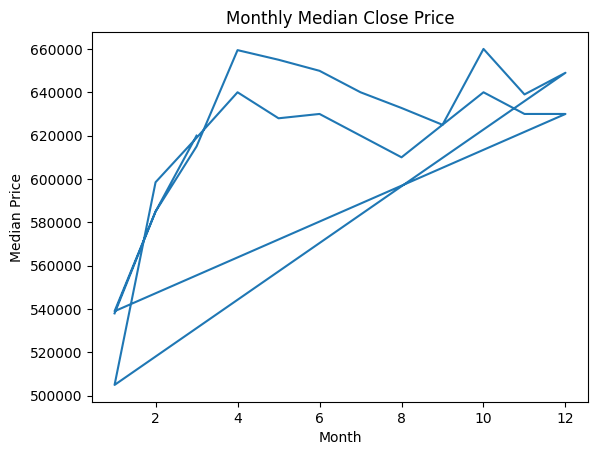

In [51]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(monthly_prices['Month'], monthly_prices['ClosePrice'])
plt.title("Monthly Median Close Price")
plt.xlabel("Month")
plt.ylabel("Median Price")
plt.show()

Monthly price trends reveal how housing prices change over time and can highlight seasonal patterns.

In [52]:
sold.to_csv("final_sold.csv", index=False)
listed.to_csv("final_listings.csv", index=False)

print("Files created successfully:")
import os
print(os.listdir())

Files created successfully:
['CRMLSSold202409.csv', 'CRMLSListing202405.csv', 'CRMLSListing202411.csv', 'eda.ipynb', 'CRMLSListing202410.csv', 'CRMLSListing202404.csv', 'CRMLSSold202408.csv', 'CRMLSListing202412.csv', 'CRMLSListing202406.csv', 'Listing Script.py', 'CRMLSListing202407.csv', 'CRMLSListing202601.csv', 'CRMLSListing202403.csv', '.DS_Store', 'CRMLSListing202402.csv', 'Sold Script.py', 'CRMLSListing202602.csv', 'CRMLSListing202401.csv', 'CRMLSListing202603.csv', 'CRMLSListing202512.csv', 'CRMLSListing202506.csv', 'CRMLSListing202507.csv', 'CRMLSListing202505.csv', 'CRMLSListing202511.csv', 'CRMLSSold202509.csv', 'CRMLSSold202508.csv', 'CRMLSListing202510.csv', 'CRMLSListing202504.csv', 'final_sold.csv', 'CRMLSListing202501.csv', 'CRMLSListing202503.csv', 'CRMLSListing202502.csv', 'CRMLSSold202503.csv', 'CRMLSSold202502.csv', 'CRMLSSold202501.csv', 'CRMLSListing202509.csv', 'CRMLSSold202505.csv', 'CRMLSSold202511.csv', 'CRMLSSold202510.csv', 'CRMLSSold202504.csv', 'CRMLSListi

## Final Summary

The MLS datasets were successfully structured and validated.

Key points:
- Data types were corrected for time analysis
- New features were created for pricing insights
- Data quality checks were performed
- Monthly trends were calculated
- Clean datasets were exported for Tableau

The data is now ready for visualization and further analysis.